# 複数カード統合判別プログラム（分離画像限定版）

複数枚のトランプが写った画像について、次の順番で処理します。

1. `cardproject/card_splitter_first.py` でカードを分離
2. 分離プログラムが作成した `cards` フォルダ内の画像だけを取得
3. 元画像・検出枠画像・二値化画像などのデバッグ画像を除外
4. `suit_cnn.pth` でスートを判定
5. `rank_multiscan_hog_svm_v2.joblib` でランクを判定
6. 実際に分離できたカードだけを配列・JSONへ出力

## 修正した問題

以前の版では、カード分離関数が戻り値を返さない場合に
`split_cards` 以下のすべての画像を検索していました。

そのため、次のような画像までカードとして誤認していました。

- 入力元画像
- 検出枠を描画した画像
- 二値化画像
- 輪郭確認画像

本版では、最初に `cards` フォルダ内だけを検索します。
`cards` フォルダが存在しない場合も、`card_1.jpg` や
`card_002.png` のような厳密なカード画像名だけを対象にします。

## Google Drive上の配置

```text
/content/drive/MyDrive/Colab Notebooks/AIseminar/
├── card_recognizer_integrated_colab_filtered.ipynb
├── 5card.jpg
├── suit_cnn.pth
├── Rank_MultiScan_HOG_SVM_v2.ipynb
├── rank_multiscan_hog_svm_v2.joblib
└── cardproject/
    └── card_splitter_first.py
```


In [1]:
from google.colab import drive

# Google DriveをColabへマウント
drive.mount("/content/drive")

Mounted at /content/drive


## 1. ファイル配置と実行設定

In [2]:
from pathlib import Path

# ==========================================================
# 統合ノートブックを配置する基準フォルダ
# ==========================================================
BASE_DIR = Path(
    "/content/drive/MyDrive/"
    "Colab Notebooks/AIseminar"
)

# ==========================================================
# 入力画像
# ==========================================================
INPUT_IMAGE_NAME = "5card.jpg"
INPUT_IMAGE_PATH = BASE_DIR / INPUT_IMAGE_NAME

# ==========================================================
# カード分離プログラム
# ==========================================================
CARDPROJECT_DIR = BASE_DIR / "cardproject"
SPLITTER_PATH = CARDPROJECT_DIR / "card_splitter_first.py"

# 関数名を自動検出できない場合だけ指定する
# 例: SPLITTER_FUNCTION = "main"
SPLITTER_FUNCTION = None

# ==========================================================
# SuitCNN
# ==========================================================
SUIT_MODEL_PATH = BASE_DIR / "suit_cnn.pth"

# ==========================================================
# Rank MultiScan v2
# 実際に保存されているファイル名を指定
# ==========================================================
RANK_NOTEBOOK_PATH = (
    BASE_DIR / "Rank_MultiScan_HOG_SVM_v2.ipynb"
)

RANK_MODEL_PATH = (
    BASE_DIR / "rank_multiscan_hog_svm_v2.joblib"
)

# ==========================================================
# 出力先
#
# AIseminar/card_recognition_results.json
# AIseminar/split_cards/card_001.png ...
# ==========================================================
OUTPUT_DIR = BASE_DIR

# autoの場合、GPUが利用可能ならGPUを使用する
DEVICE_NAME = "auto"

print("基準フォルダ:", BASE_DIR)
print("入力画像:", INPUT_IMAGE_PATH)
print("カード分離プログラム:", SPLITTER_PATH)
print("SuitCNNモデル:", SUIT_MODEL_PATH)
print("Rankノートブック:", RANK_NOTEBOOK_PATH)
print("Rankモデル:", RANK_MODEL_PATH)
print("出力フォルダ:", OUTPUT_DIR)

基準フォルダ: /content/drive/MyDrive/Colab Notebooks/AIseminar
入力画像: /content/drive/MyDrive/Colab Notebooks/AIseminar/5card.jpg
カード分離プログラム: /content/drive/MyDrive/Colab Notebooks/AIseminar/cardproject/card_splitter_first.py
SuitCNNモデル: /content/drive/MyDrive/Colab Notebooks/AIseminar/suit_cnn.pth
Rankノートブック: /content/drive/MyDrive/Colab Notebooks/AIseminar/Rank_MultiScan_HOG_SVM_v2.ipynb
Rankモデル: /content/drive/MyDrive/Colab Notebooks/AIseminar/rank_multiscan_hog_svm_v2.joblib
出力フォルダ: /content/drive/MyDrive/Colab Notebooks/AIseminar


## 2. 統合判別処理の定義

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""複数枚のトランプ画像を分離し、スートとランクを統合判定する。

処理の流れ
----------
1. ``card_splitter_first.py`` を動的に読み込む。
2. 入力画像をカード1枚ごとの画像へ分離する。
3. ``suit_cnn.pth`` を使ってスートを判定する。
4. 既存のRank MultiScanノートブックから関数定義だけを読み込む。
5. ``rank_multiscan_hog_svm_v2.joblib`` を使ってランクを判定する。
6. 枚数ラベルと判定結果を配列・JSONとして表示し、保存する。

Rankノートブックの学習処理や評価処理は実行しない。
``prepare_unknown_sample`` と ``predict_sample``、およびそれらが利用する
関数定義のみを抽出して推論へ利用する。
"""

import argparse
import ast
import importlib.util
import inspect
import math
import os
import random
import re
import json
import shutil
import sys
from collections import Counter
from dataclasses import asdict, dataclass
from pathlib import Path
from types import ModuleType
from typing import Any, Callable, Iterable, Sequence

import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from PIL import Image


IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

SUIT_JAPANESE = {
    "c": "クラブ",
    "d": "ダイヤ",
    "h": "ハート",
    "s": "スペード",
}

RANK_DISPLAY = {
    1: "A",
    11: "J",
    12: "Q",
    13: "K",
}


class IntegrationError(RuntimeError):
    """統合処理を続行できない場合の例外。"""


class SuitCNN(nn.Module):
    """SuitCNN_suit_only.ipynb と同じ4クラスCNN。"""

    def __init__(self, num_classes: int = 4) -> None:
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.classifier(self.features(x))


@dataclass
class SuitResult:
    code: str
    name: str
    confidence: float
    probabilities: list[float]


@dataclass
class RankResult:
    rank: int | None
    confidence: float | None
    margin: float | None
    accepted: bool
    probabilities: list[float] | None
    raw_type: str


@dataclass
class CardRecognition:
    card_index: int
    count_label: str
    image_path: str
    suit_code: str
    suit: str
    rank: int | None
    rank_label: str
    card_label: str
    suit_confidence: float
    rank_confidence: float | None
    rank_margin: float | None
    accepted: bool


# ==========================================================
# 共通ユーティリティ
# ==========================================================


def load_python_module(path: Path, module_name: str) -> ModuleType:
    """指定されたPythonファイルを動的に読み込む。"""

    path = path.resolve()
    if not path.is_file():
        raise FileNotFoundError(f"Pythonモジュールが見つかりません: {path}")

    spec = importlib.util.spec_from_file_location(module_name, path)
    if spec is None or spec.loader is None:
        raise ImportError(f"Pythonモジュールを読み込めません: {path}")

    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


def select_device(device_name: str) -> torch.device:
    if device_name == "auto":
        return torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    device = torch.device(device_name)
    if device.type == "cuda" and not torch.cuda.is_available():
        raise IntegrationError("CUDAを指定しましたが、CUDAを利用できません。")
    return device


def load_torch_checkpoint(path: Path, device: torch.device) -> Any:
    """PyTorchの版差を吸収してチェックポイントを読み込む。"""

    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def image_to_rgb_pil(value: Any) -> Image.Image:
    """PIL・NumPy配列・パスをRGBのPIL画像へ変換する。"""

    if isinstance(value, Image.Image):
        return value.convert("RGB")

    if isinstance(value, (str, Path)):
        path = Path(value)
        if not path.is_file():
            raise FileNotFoundError(f"画像が見つかりません: {path}")
        return Image.open(path).convert("RGB")

    if isinstance(value, np.ndarray):
        array = value
        if array.ndim == 2:
            return Image.fromarray(array.astype(np.uint8), mode="L").convert("RGB")

        if array.ndim != 3 or array.shape[2] not in (3, 4):
            raise ValueError(f"未対応の画像配列形状です: {array.shape}")

        if array.dtype != np.uint8:
            array = np.clip(array, 0, 255).astype(np.uint8)

        if array.shape[2] == 4:
            return Image.fromarray(array, mode="RGBA").convert("RGB")

        # OpenCV由来かRGB由来かは自動判定できないため、
        # splitter側でRGB配列を返すことを基本とする。
        return Image.fromarray(array, mode="RGB")

    raise TypeError(f"画像へ変換できない型です: {type(value).__name__}")


def rank_to_display(rank: int | None) -> str:
    if rank is None:
        return "?"
    return RANK_DISPLAY.get(rank, str(rank))


def _normalise_probability_list(value: Any) -> list[float] | None:
    if value is None:
        return None

    try:
        array = np.asarray(value, dtype=np.float64).reshape(-1)
    except (TypeError, ValueError):
        return None

    if array.size == 0:
        return None

    return [float(item) for item in array.tolist()]


# ==========================================================
# SuitCNN
# ==========================================================


class SuitClassifier:
    def __init__(self, model_path: Path, device: torch.device) -> None:
        if not model_path.is_file():
            raise FileNotFoundError(f"SuitCNNモデルが見つかりません: {model_path}")

        checkpoint = load_torch_checkpoint(model_path, device)

        if not isinstance(checkpoint, dict):
            raise IntegrationError(
                "SuitCNNのチェックポイント形式が辞書ではありません。"
            )

        state_dict = checkpoint.get("model_state_dict", checkpoint)
        class_names = checkpoint.get("class_names", ["c", "d", "h", "s"])
        self.class_names = [str(name).lower() for name in class_names]
        self.image_size = int(checkpoint.get("image_size", 128))
        self.device = device

        self.model = SuitCNN(num_classes=len(self.class_names)).to(device)
        self.model.load_state_dict(state_dict, strict=True)
        self.model.eval()

    def _preprocess(self, image: Image.Image) -> torch.Tensor:
        resized = image.convert("RGB").resize(
            (self.image_size, self.image_size),
            resample=Image.Resampling.BILINEAR,
        )

        array = np.asarray(resized, dtype=np.float32) / 255.0
        tensor = torch.from_numpy(array.transpose(2, 0, 1))

        # 学習ノートブックの Normalize(mean=.5, std=.5) と同じ。
        tensor = (tensor - 0.5) / 0.5
        return tensor.unsqueeze(0).to(self.device)

    def predict(self, image_value: Any) -> SuitResult:
        image = image_to_rgb_pil(image_value)
        image_tensor = self._preprocess(image)

        with torch.inference_mode():
            logits = self.model(image_tensor)
            probabilities = torch.softmax(logits, dim=1)[0]

        predicted_index = int(torch.argmax(probabilities).item())
        suit_code = self.class_names[predicted_index]

        return SuitResult(
            code=suit_code,
            name=SUIT_JAPANESE.get(suit_code, suit_code),
            confidence=float(probabilities[predicted_index].item()),
            probabilities=[float(value) for value in probabilities.cpu().tolist()],
        )


# ==========================================================
# card_splitter_first.py 接続
# ==========================================================


class CardSplitterAdapter:
    """card_splitter_first.py の代表的な関数形式を吸収する。"""

    FUNCTION_CANDIDATES = (
        "split_cards",
        "detect_and_split_cards",
        "extract_cards",
        "split_card_images",
        "process_image",
        "run",
    )

    METHOD_CANDIDATES = (
        "split_cards",
        "detect_and_split_cards",
        "extract_cards",
        "process",
        "predict",
    )

    def __init__(self, module_path: Path, function_name: str | None = None) -> None:
        self.module_path = module_path
        self.module = load_python_module(module_path, "card_splitter_first_runtime")
        self.callable = self._resolve_callable(function_name)

    def _resolve_callable(self, function_name: str | None) -> Callable[..., Any]:
        if function_name:
            function = getattr(self.module, function_name, None)
            if not callable(function):
                raise IntegrationError(
                    f"splitter関数 '{function_name}' がありません: {self.module_path}"
                )
            return function

        for name in self.FUNCTION_CANDIDATES:
            function = getattr(self.module, name, None)
            if callable(function):
                return function

        splitter_class = getattr(self.module, "CardSplitter", None)
        if inspect.isclass(splitter_class):
            try:
                instance = splitter_class()
            except TypeError as error:
                raise IntegrationError(
                    "CardSplitterの生成に引数が必要です。"
                    "関数形式のsplit_cardsを用意するか、生成処理を調整してください。"
                ) from error

            for name in self.METHOD_CANDIDATES:
                method = getattr(instance, name, None)
                if callable(method):
                    return method

        candidates = ", ".join(self.FUNCTION_CANDIDATES)
        raise IntegrationError(
            "card_splitter_first.pyに利用可能な関数がありません。"
            f"候補: {candidates}。--splitter-functionで明示指定もできます。"
        )

    @staticmethod
    def _call_splitter(
        function: Callable[..., Any],
        input_path: Path,
        output_dir: Path,
    ) -> Any:
        """関数の引数名から入力画像・出力先を割り当てる。"""

        signature = inspect.signature(function)
        parameters = list(signature.parameters.values())
        keyword_arguments: dict[str, Any] = {}
        positional_arguments: list[Any] = []

        input_names = {
            "image_path",
            "input_path",
            "source_path",
            "filename",
            "file_path",
            "path",
            "image_file",
        }
        output_names = {
            "output_dir",
            "save_dir",
            "output_directory",
            "save_directory",
            "destination",
            "destination_dir",
        }

        for parameter in parameters:
            if parameter.kind in (
                inspect.Parameter.VAR_POSITIONAL,
                inspect.Parameter.VAR_KEYWORD,
            ):
                continue

            lower_name = parameter.name.lower()
            if lower_name in input_names:
                keyword_arguments[parameter.name] = str(input_path)
            elif lower_name in output_names:
                keyword_arguments[parameter.name] = str(output_dir)
            elif parameter.default is inspect.Parameter.empty:
                # 名前が独自の場合は、必須引数の出現順で補う。
                if not positional_arguments:
                    positional_arguments.append(str(input_path))
                elif len(positional_arguments) == 1:
                    positional_arguments.append(str(output_dir))
                else:
                    raise IntegrationError(
                        "splitter関数の必須引数を自動判定できません: "
                        f"{signature}"
                    )

        try:
            return function(*positional_arguments, **keyword_arguments)
        except TypeError:
            # キーワードと位置引数の重複など、独自シグネチャ用の安全な再試行。
            required_count = sum(
                parameter.default is inspect.Parameter.empty
                and parameter.kind
                in (
                    inspect.Parameter.POSITIONAL_ONLY,
                    inspect.Parameter.POSITIONAL_OR_KEYWORD,
                )
                for parameter in parameters
            )

            if required_count <= 1:
                return function(str(input_path))
            if required_count == 2:
                return function(str(input_path), str(output_dir))
            raise

    @staticmethod
    def _flatten_splitter_result(value: Any) -> list[Any]:
        if value is None:
            return []

        if isinstance(value, dict):
            for key in (
                "cards",
                "card_images",
                "card_paths",
                "results",
                "detections",
                "images",
            ):
                if key in value:
                    return CardSplitterAdapter._flatten_splitter_result(value[key])

            # 1枚分の辞書を保持する。
            if any(
                key in value
                for key in (
                    "path",
                    "image_path",
                    "card_path",
                    "image",
                    "card",
                    "crop",
                )
            ):
                return [value]

            flattened: list[Any] = []
            for nested_value in value.values():
                flattened.extend(
                    CardSplitterAdapter._flatten_splitter_result(nested_value)
                )
            return flattened

        if isinstance(value, (list, tuple)):
            # (cards, annotated_image) の形式では cards を優先する。
            if len(value) == 2 and isinstance(value[0], (list, tuple, dict)):
                first = CardSplitterAdapter._flatten_splitter_result(value[0])
                if first:
                    return first

            flattened = []
            for item in value:
                flattened.extend(CardSplitterAdapter._flatten_splitter_result(item))
            return flattened

        return [value]

    @staticmethod
    def _extract_image_value(item: Any) -> Any:
        if not isinstance(item, dict):
            return item

        for key in (
            "path",
            "image_path",
            "card_path",
            "image",
            "card",
            "crop",
        ):
            if key in item:
                return item[key]

        raise ValueError(f"カード辞書内に画像データがありません: {item.keys()}")

    @staticmethod
    def _natural_card_sort_key(
        path: Path,
    ) -> tuple[Any, ...]:
        """card_2をcard_10より前へ並べる自然順キーを返す。"""

        parts = re.split(
            r"(\d+)",
            path.name.lower(),
        )

        return tuple(
            int(part)
            if part.isdigit()
            else part
            for part in parts
        )

    @staticmethod
    def _is_cards_directory(
        directory: Path,
        output_dir: Path,
    ) -> bool:
        """分離カード専用フォルダか判定する。"""

        output_dir = output_dir.resolve()

        try:
            relative_parts = directory.resolve().relative_to(
                output_dir
            ).parts
        except ValueError:
            return False

        accepted_directory_names = {
            "cards",
            "card",
            "card_images",
            "card_crops",
            "cropped_cards",
            "detected_cards",
        }

        return any(
            part.lower() in accepted_directory_names
            for part in relative_parts
        )

    @classmethod
    def _scan_output_images(
        cls,
        output_dir: Path,
    ) -> list[Path]:
        """デバッグ画像を除外し、分離カード画像だけを取得する。

        優先順位
        ----------
        1. cards/card_images/card_crops等の専用フォルダ内
        2. card_1.jpg、card_002.png等の厳密なファイル名

        入力元画像、annotated、binary、threshold、contour等は
        判定対象へ追加しない。
        """

        all_images = [
            path
            for path in output_dir.rglob("*")
            if (
                path.is_file()
                and path.suffix.lower()
                in IMAGE_EXTENSIONS
            )
        ]

        # card_splitter_first.pyの現在の出力:
        # split_cards/<入力名>/cards/card_1.jpg
        preferred_images = [
            path.resolve()
            for path in all_images
            if cls._is_cards_directory(
                path.parent,
                output_dir,
            )
        ]

        if preferred_images:
            return sorted(
                dict.fromkeys(preferred_images),
                key=cls._natural_card_sort_key,
            )

        # 専用フォルダがないsplitter向けの安全な代替。
        # 「card」という語を含むだけでは認めず、
        # card_番号、card-番号、card番号の形式に限定する。
        strict_card_pattern = re.compile(
            r"^(?:card|crop)[_-]?\d+$",
            re.IGNORECASE,
        )

        strict_images = [
            path.resolve()
            for path in all_images
            if strict_card_pattern.fullmatch(
                path.stem
            )
        ]

        return sorted(
            dict.fromkeys(strict_images),
            key=cls._natural_card_sort_key,
        )

    def split(self, input_path: Path, output_dir: Path) -> list[Path]:
        output_dir.mkdir(parents=True, exist_ok=True)

        raw_result = self._call_splitter(self.callable, input_path, output_dir)
        items = self._flatten_splitter_result(raw_result)

        card_paths: list[Path] = []
        seen_resolved_paths: set[Path] = set()

        for index, item in enumerate(items, start=1):
            image_value = self._extract_image_value(item)

            if isinstance(image_value, (str, Path)):
                source_path = Path(image_value)
                if not source_path.is_absolute():
                    candidates = [
                        Path.cwd() / source_path,
                        output_dir / source_path,
                        self.module_path.parent / source_path,
                    ]
                    source_path = next(
                        (candidate for candidate in candidates if candidate.is_file()),
                        source_path,
                    )

                if source_path.is_file():
                    resolved = source_path.resolve()
                    if resolved in seen_resolved_paths:
                        continue
                    seen_resolved_paths.add(resolved)

                    destination = output_dir / f"card_{len(card_paths) + 1:03d}.png"
                    image_to_rgb_pil(source_path).save(destination)
                    card_paths.append(destination)
                    continue

            destination = output_dir / f"card_{len(card_paths) + 1:03d}.png"
            image_to_rgb_pil(image_value).save(destination)
            card_paths.append(destination)

        # splitterがファイル保存のみを行い、戻り値がない形式にも対応する。
        # cardsフォルダ内または厳密なcard_番号形式だけを取得する。
        if not card_paths:
            card_paths = self._scan_output_images(
                output_dir
            )

            print(
                "統合処理対象カード数:",
                len(card_paths),
            )

            for detected_index, source_path in enumerate(
                card_paths,
                start=1,
            ):
                print(
                    f"  対象{detected_index}:",
                    source_path,
                )

        # 結果順を自然順で安定化する。
        card_paths = sorted(
            dict.fromkeys(
                path.resolve()
                for path in card_paths
            ),
            key=self._natural_card_sort_key,
        )

        if not card_paths:
            raise IntegrationError(
                "カードを1枚も分離できませんでした。"
                "card_splitter_first.pyがcardsフォルダへ"
                "分離カードを保存しているか確認してください。"
            )

        return card_paths


# ==========================================================
# Rank MultiScan 接続
# ==========================================================


def build_rank_runtime_namespace(
    model_bundle: dict[str, Any],
) -> dict[str, Any]:
    """Rank MultiScan v2の関数が参照する名前空間を作成する。"""

    default_scan_window_sizes = [
        (0.18, 0.12),
        (0.22, 0.14),
        (0.26, 0.16),
        (0.30, 0.18),
        (0.34, 0.20),
        (0.38, 0.22),
        (0.42, 0.25),
    ]

    default_scan_offsets = [
        (0.000, 0.000),
        (0.015, 0.010),
        (0.030, 0.020),
        (0.045, 0.030),
    ]

    namespace: dict[str, Any] = {
        "__builtins__": __builtins__,
        "ast": ast,
        "cv2": cv2,
        "joblib": joblib,
        "math": math,
        "np": np,
        "os": os,
        "plt": plt,
        "random": random,
        "re": re,
        "shutil": shutil,
        "Counter": Counter,
        "Image": Image,
        "Path": Path,

        # カード検出
        "NUM_CLASSES": 13,
        "CARD_WIDTH": 600,
        "CARD_HEIGHT": 900,
        "MAX_CARD_QUAD_CANDIDATES": 4,
        "QUAD_EXPANSION": 1.045,
        "MAX_RANK_PAIR_CANDIDATES": 5,
        "MAX_COMPONENT_CANDIDATES_PER_SIDE": 4,

        # 多範囲走査
        "SCAN_WINDOW_SIZES": model_bundle.get(
            "scan_window_sizes",
            default_scan_window_sizes,
        ),
        "SCAN_OFFSETS": model_bundle.get(
            "scan_offsets",
            default_scan_offsets,
        ),
        "ORIENTATION_ROTATIONS": [
            0,
            90,
            180,
            270,
        ],

        # 抽出品質
        "QUALITY_REJECTION_PERCENTILE": 15,
        "MIN_EXTRACTION_QUALITY": 0.30,
        "MIN_SAMPLES_PER_CLASS": 4,
        "ALTERNATIVE_CANDIDATE_SCORE_GAP": 0.10,
        "MAX_ALTERNATIVE_CANDIDATES_FOR_TRAIN": 3,

        # HOG・SVM・テンプレート
        "HOG_IMAGE_SIZE": 64,
        "SVM_KERNEL": "rbf",
        "SVM_C": 10.0,
        "SVM_GAMMA": "scale",
        "SVM_WEIGHT": 0.80,
        "TEMPLATE_WEIGHT": 0.20,
        "TOP_BASE_WEIGHT": 0.65,
        "BOTTOM_BASE_WEIGHT": 0.35,
        "TEMPLATE_TOP_K": 3,
        "TEMPLATE_TEMPERATURE": 0.08,

        # 推論時の候補選択
        "CLASSIFIER_CONFIDENCE_WEIGHT": 0.55,
        "CLASSIFIER_MARGIN_WEIGHT": 0.20,
        "EXTRACTION_SCORE_WEIGHT": 0.25,
        "CONFIDENCE_THRESHOLD": 0.38,
        "MARGIN_THRESHOLD": 0.07,
        "EXTRACTION_ACCEPT_THRESHOLD": 0.30,

        # その他
        "USE_AUGMENTATION": True,
        "CV_MODE": "stratified",
        "REQUESTED_SPLITS": 5,
        "SEED": 42,
        "IMAGE_EXTENSIONS": {
            ".jpg",
            ".jpeg",
            ".png",
            ".bmp",
        },
    }

    namespace["HOG_DESCRIPTOR"] = cv2.HOGDescriptor(
        (64, 64),
        (16, 16),
        (8, 8),
        (8, 8),
        9,
    )

    return namespace


def load_rank_functions_from_notebook(
    notebook_path: Path,
    model_bundle: dict[str, Any],
) -> dict[str, Any]:
    """Rankノートブックから関数定義だけを読み込む。

    データセット読込、学習、交差検証、グラフ表示などのトップレベル処理は
    実行しない。各コードセルをASTで解析し、関数定義のみを共通名前空間へ
    登録する。
    """

    if not notebook_path.is_file():
        raise FileNotFoundError(
            f"Rankノートブックが見つかりません: {notebook_path}"
        )

    with notebook_path.open(
        "r",
        encoding="utf-8",
    ) as file:
        notebook_data = json.load(file)

    namespace = build_rank_runtime_namespace(
        model_bundle
    )

    loaded_function_names: list[str] = []
    skipped_functions: dict[str, str] = {}

    for cell_index, cell in enumerate(
        notebook_data.get("cells", [])
    ):
        if cell.get("cell_type") != "code":
            continue

        source = "".join(
            cell.get("source", [])
        )

        if not source.strip():
            continue

        try:
            parsed = ast.parse(
                source,
                filename=(
                    f"{notebook_path.name}"
                    f":cell_{cell_index}"
                ),
            )
        except SyntaxError:
            # マジックコマンド等を含むセルは推論関数抽出の対象外
            continue

        for node in parsed.body:
            if not isinstance(
                node,
                (
                    ast.FunctionDef,
                    ast.AsyncFunctionDef,
                ),
            ):
                continue

            # final_model_bundleを既定値に使う表示用関数は不要。
            if node.name == "predict_unknown_image":
                continue

            function_module = ast.Module(
                body=[node],
                type_ignores=[],
            )
            ast.fix_missing_locations(
                function_module
            )

            try:
                exec(
                    compile(
                        function_module,
                        filename=(
                            f"{notebook_path.name}"
                            f":{node.name}"
                        ),
                        mode="exec",
                    ),
                    namespace,
                )
                loaded_function_names.append(
                    node.name
                )
            except Exception as error:
                # 推論に不要な学習用関数で、定義時に外部名が必要な場合は保留する。
                skipped_functions[node.name] = (
                    f"{type(error).__name__}: {error}"
                )

    required_functions = (
        "prepare_unknown_sample",
        "predict_sample",
    )

    missing_functions = [
        function_name
        for function_name in required_functions
        if not callable(
            namespace.get(function_name)
        )
    ]

    if missing_functions:
        raise IntegrationError(
            "Rankノートブックから必要な推論関数を読み込めませんでした: "
            + ", ".join(missing_functions)
        )

    print(
        "Rank関数読込数:",
        len(set(loaded_function_names)),
    )

    if skipped_functions:
        print(
            "推論に不要なため読込を省略した関数数:",
            len(skipped_functions),
        )

    return namespace


class RankMultiScanAdapter:
    """既存RankノートブックとJoblibを用いてランクを判定する。"""

    def __init__(
        self,
        notebook_path: Path,
        model_path: Path,
    ) -> None:
        if not model_path.is_file():
            raise FileNotFoundError(
                f"ランクモデルが見つかりません: {model_path}"
            )

        self.notebook_path = notebook_path
        self.model_path = model_path
        self.model_bundle = joblib.load(
            model_path
        )

        model_version = self.model_bundle.get(
            "model_version",
            "記録なし",
        )
        print(
            "Rank model version:",
            model_version,
        )

        if (
            model_version != "記録なし"
            and model_version
            != "multi_scan_hog_svm_v2"
        ):
            print(
                "[WARNING] Rankモデルのversionが"
                "multi_scan_hog_svm_v2ではありません。"
            )

        self.runtime_namespace = (
            load_rank_functions_from_notebook(
                notebook_path=notebook_path,
                model_bundle=self.model_bundle,
            )
        )

        self.prepare_unknown_sample = (
            self.runtime_namespace[
                "prepare_unknown_sample"
            ]
        )
        self.predict_sample = (
            self.runtime_namespace[
                "predict_sample"
            ]
        )

    def _normalise_rank_result(
        self,
        raw_result: Any,
    ) -> RankResult:
        raw_type = type(
            raw_result
        ).__name__

        if isinstance(
            raw_result,
            RankResult,
        ):
            return raw_result

        if not isinstance(
            raw_result,
            dict,
        ):
            raise IntegrationError(
                "Rank MultiScanの推論結果が"
                "辞書形式ではありません: "
                f"{raw_type}"
            )

        rank: int | None = None

        for key in (
            "rank",
            "predicted_rank",
            "rank_number",
            "class_name",
        ):
            if (
                key in raw_result
                and raw_result[key] is not None
            ):
                try:
                    rank = int(
                        raw_result[key]
                    )
                except (
                    TypeError,
                    ValueError,
                ):
                    rank = None
                break

        # Rank MultiScanノートブックのpredictionは0～12。
        if (
            rank is None
            and raw_result.get(
                "prediction"
            ) is not None
        ):
            prediction = int(
                raw_result[
                    "prediction"
                ]
            )
            rank = (
                prediction + 1
                if 0 <= prediction <= 12
                else prediction
            )

        probabilities = None

        for key in (
            "probability",
            "probabilities",
            "class_probabilities",
        ):
            if key in raw_result:
                probabilities = (
                    _normalise_probability_list(
                        raw_result[key]
                    )
                )
                break

        confidence_value = (
            raw_result.get(
                "confidence",
                raw_result.get(
                    "score",
                    raw_result.get(
                        "probability_score"
                    ),
                ),
            )
        )

        confidence = (
            float(confidence_value)
            if (
                confidence_value is not None
                and np.isscalar(
                    confidence_value
                )
            )
            else None
        )

        if (
            confidence is None
            and probabilities
        ):
            confidence = float(
                max(probabilities)
            )

        margin_value = raw_result.get(
            "margin"
        )
        margin = (
            float(margin_value)
            if margin_value is not None
            else None
        )

        accepted = bool(
            raw_result.get(
                "accepted",
                raw_result.get(
                    "is_accepted",
                    True,
                ),
            )
        )

        if rank is not None and not (
            1 <= rank <= 13
        ):
            raise IntegrationError(
                "ランクが1～13の範囲外です: "
                f"{rank}"
            )

        return RankResult(
            rank=rank,
            confidence=confidence,
            margin=margin,
            accepted=accepted,
            probabilities=probabilities,
            raw_type=raw_type,
        )

    def predict(
        self,
        image_path: Path,
    ) -> RankResult:
        sample = self.prepare_unknown_sample(
            str(image_path)
        )

        raw_result = self.predict_sample(
            sample,
            self.model_bundle,
        )

        return self._normalise_rank_result(
            raw_result
        )


# ==========================================================
# 統合判定
# ==========================================================


class CardRecognizer:
    def __init__(
        self,
        splitter: CardSplitterAdapter,
        suit_classifier: SuitClassifier,
        rank_classifier: RankMultiScanAdapter,
    ) -> None:
        self.splitter = splitter
        self.suit_classifier = suit_classifier
        self.rank_classifier = rank_classifier

    def recognize(self, input_path: Path, output_dir: Path) -> list[CardRecognition]:
        cards_dir = output_dir / "split_cards"
        if cards_dir.exists():
            shutil.rmtree(cards_dir)
        cards_dir.mkdir(parents=True, exist_ok=True)

        card_paths = self.splitter.split(input_path, cards_dir)
        results: list[CardRecognition] = []

        for card_index, card_path in enumerate(card_paths, start=1):
            suit_result = self.suit_classifier.predict(card_path)
            rank_result = self.rank_classifier.predict(card_path)

            rank_label = rank_to_display(rank_result.rank)
            accepted = rank_result.accepted and rank_result.rank is not None

            if accepted:
                card_label = f"{suit_result.name}{rank_label}"
            else:
                card_label = f"{suit_result.name}{rank_label}（判定保留）"

            results.append(
                CardRecognition(
                    card_index=card_index,
                    count_label=f"{card_index}枚目",
                    image_path=str(card_path),
                    suit_code=suit_result.code,
                    suit=suit_result.name,
                    rank=rank_result.rank,
                    rank_label=rank_label,
                    card_label=card_label,
                    suit_confidence=suit_result.confidence,
                    rank_confidence=rank_result.confidence,
                    rank_margin=rank_result.margin,
                    accepted=accepted,
                )
            )

        return results


# ==========================================================
# 表示・保存
# ==========================================================


def result_payload(results: Sequence[CardRecognition]) -> dict[str, Any]:
    return {
        "detected_count": len(results),
        "count_labels": [result.count_label for result in results],
        "detection_results": [result.card_label for result in results],
        "cards": [asdict(result) for result in results],
    }


def print_results(payload: dict[str, Any]) -> None:
    print("\n" + "=" * 64)
    print("カード判別結果")
    print("=" * 64)
    print("検出枚数:", payload["detected_count"])
    print("枚数ラベル配列:", payload["count_labels"])
    print("検出結果配列:", payload["detection_results"])

    print("\n統合結果配列:")
    print(json.dumps(payload["cards"], ensure_ascii=False, indent=2))


def save_results(payload: dict[str, Any], output_dir: Path) -> Path:
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / "card_recognition_results.json"
    output_path.write_text(
        json.dumps(payload, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    return output_path




## 3. 必要ファイルの確認

In [4]:
required_files = {
    "入力画像": INPUT_IMAGE_PATH,
    "カード分離プログラム": SPLITTER_PATH,
    "SuitCNN学習済みモデル": SUIT_MODEL_PATH,
    "Rank MultiScan v2ノートブック": RANK_NOTEBOOK_PATH,
    "Rank MultiScan v2学習済みモデル": RANK_MODEL_PATH,
}

missing_files = []

for label, file_path in required_files.items():
    exists = file_path.is_file()
    mark = "OK" if exists else "NG"

    print(
        f"[{mark}] {label}: {file_path}"
    )

    if not exists:
        missing_files.append(
            (
                label,
                file_path,
            )
        )

if missing_files:
    missing_text = "\n".join(
        f"- {label}: {file_path}"
        for label, file_path
        in missing_files
    )

    raise FileNotFoundError(
        "必要ファイルが見つかりません。\n"
        "Google Drive上のファイル名と配置を"
        "確認してください。\n"
        f"{missing_text}"
    )

print(
    "\nすべての必要ファイルを確認しました。"
)

[OK] 入力画像: /content/drive/MyDrive/Colab Notebooks/AIseminar/5card.jpg
[OK] カード分離プログラム: /content/drive/MyDrive/Colab Notebooks/AIseminar/cardproject/card_splitter_first.py
[OK] SuitCNN学習済みモデル: /content/drive/MyDrive/Colab Notebooks/AIseminar/suit_cnn.pth
[OK] Rank MultiScan v2ノートブック: /content/drive/MyDrive/Colab Notebooks/AIseminar/Rank_MultiScan_HOG_SVM_v2.ipynb
[OK] Rank MultiScan v2学習済みモデル: /content/drive/MyDrive/Colab Notebooks/AIseminar/rank_multiscan_hog_svm_v2.joblib

すべての必要ファイルを確認しました。


## 4. カードの分離と統合判定

In [5]:
# 実行デバイスを選択
device = select_device(
    DEVICE_NAME
)
print("使用デバイス:", device)

# カード分離処理を読み込む
splitter = CardSplitterAdapter(
    module_path=SPLITTER_PATH,
    function_name=SPLITTER_FUNCTION,
)

# SuitCNNを読み込む
suit_classifier = SuitClassifier(
    model_path=SUIT_MODEL_PATH,
    device=device,
)

# 既存Rankノートブックから関数定義だけを読み込み、
# 保存済みJoblibで推論する
rank_classifier = RankMultiScanAdapter(
    notebook_path=RANK_NOTEBOOK_PATH,
    model_path=RANK_MODEL_PATH,
)

# 統合判別器を作成
recognizer = CardRecognizer(
    splitter=splitter,
    suit_classifier=suit_classifier,
    rank_classifier=rank_classifier,
)

# 複数カード画像を分離し、1枚ずつ判別
recognition_results = recognizer.recognize(
    input_path=INPUT_IMAGE_PATH,
    output_dir=OUTPUT_DIR,
)

print(
    "\n実際に判定へ使用した分離カード数:",
    len(recognition_results),
)

# 配列形式へ統合
payload = result_payload(
    recognition_results
)

# Colab上へ表示
print_results(
    payload
)

# AIseminar直下へJSON保存
json_output_path = save_results(
    payload=payload,
    output_dir=OUTPUT_DIR,
)

print(
    "\nJSON保存先:",
    json_output_path,
)
print(
    "分離画像保存先:",
    OUTPUT_DIR / "split_cards",
)

使用デバイス: cpu
Rank model version: multi_scan_hog_svm_v2
Rank関数読込数: 42

画像: 5card.jpg
検出カード数: 2
card_1: bbox=(52, 437, 250, 371), aspect=1.51, 
card_2: bbox=(316, 446, 247, 365), aspect=1.49, 
統合処理対象カード数: 2
  対象1: /content/drive/MyDrive/Colab Notebooks/AIseminar/split_cards/5card/cards/card_1.jpg
  対象2: /content/drive/MyDrive/Colab Notebooks/AIseminar/split_cards/5card/cards/card_2.jpg

実際に判定へ使用した分離カード数: 2

カード判別結果
検出枚数: 2
枚数ラベル配列: ['1枚目', '2枚目']
検出結果配列: ['スペード10', 'スペード10']

統合結果配列:
[
  {
    "card_index": 1,
    "count_label": "1枚目",
    "image_path": "/content/drive/MyDrive/Colab Notebooks/AIseminar/split_cards/5card/cards/card_1.jpg",
    "suit_code": "s",
    "suit": "スペード",
    "rank": 10,
    "rank_label": "10",
    "card_label": "スペード10",
    "suit_confidence": 0.9257286787033081,
    "rank_confidence": 0.6493844091808951,
    "rank_margin": 0.5316281630007001,
    "accepted": true
  },
  {
    "card_index": 2,
    "count_label": "2枚目",
    "image_path": "/content/drive/MyDrive/Co

## 5. 必要な配列だけを取得

In [6]:
# 検出されたカードの枚数
detected_count = payload["detected_count"]

# 「1枚目」「2枚目」などの枚数ラベル
count_label_array = payload["count_labels"]

# 「ハート7」「スペードK」などの判定結果
detection_result_array = payload["detection_results"]

# スートとランクを分けた配列
suit_array = [
    card["suit"]
    for card in payload["cards"]
]

rank_array = [
    card["rank_label"]
    for card in payload["cards"]
]

print("検出枚数:", detected_count)
print("枚数ラベル配列:", count_label_array)
print("検出結果配列:", detection_result_array)
print("スート配列:", suit_array)
print("ランク配列:", rank_array)

検出枚数: 2
枚数ラベル配列: ['1枚目', '2枚目']
検出結果配列: ['スペード10', 'スペード10']
スート配列: ['スペード', 'スペード']
ランク配列: ['10', '10']


## 6. 分離されたカード画像と判定結果の表示

/tmp/ipykernel_1065/4245363355.py:34: UserWarning: Glyph 26522 (\N{CJK UNIFIED IDEOGRAPH-679A}) missing from font(s) DejaVu Sans.
  figure.tight_layout()
/tmp/ipykernel_1065/4245363355.py:34: UserWarning: Glyph 30446 (\N{CJK UNIFIED IDEOGRAPH-76EE}) missing from font(s) DejaVu Sans.
  figure.tight_layout()
/tmp/ipykernel_1065/4245363355.py:34: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  figure.tight_layout()
/tmp/ipykernel_1065/4245363355.py:34: UserWarning: Glyph 12506 (\N{KATAKANA LETTER PE}) missing from font(s) DejaVu Sans.
  figure.tight_layout()
/tmp/ipykernel_1065/4245363355.py:34: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  figure.tight_layout()
/tmp/ipykernel_1065/4245363355.py:34: UserWarning: Glyph 12489 (\N{KATAKANA LETTER DO}) missing from font(s) DejaVu Sans.
  figure.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Gly

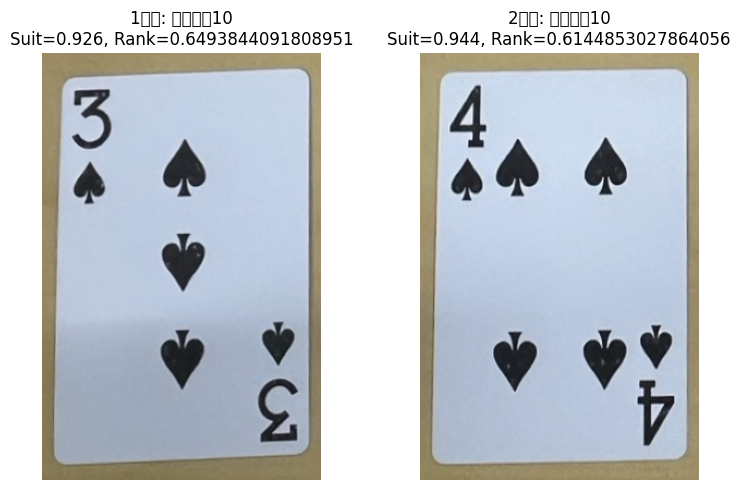

In [7]:
import math

import matplotlib.pyplot as plt
from PIL import Image

cards = payload["cards"]

if not cards:
    print("表示できるカードがありません。")
else:
    column_count = min(4, len(cards))
    row_count = math.ceil(len(cards) / column_count)

    figure = plt.figure(
        figsize=(4 * column_count, 5 * row_count)
    )

    for plot_index, card in enumerate(cards, start=1):
        axis = figure.add_subplot(
            row_count,
            column_count,
            plot_index,
        )

        card_image = Image.open(card["image_path"]).convert("RGB")
        axis.imshow(card_image)
        axis.set_title(
            f'{card["count_label"]}: {card["card_label"]}\n'
            f'Suit={card["suit_confidence"]:.3f}, '
            f'Rank={card["rank_confidence"]}'
        )
        axis.axis("off")

    figure.tight_layout()
    plt.show()

## 出力と判定対象

カード分離プログラムの出力例：

```text
AIseminar/split_cards/
└── 5card/
    ├── cards/
    │   ├── card_1.jpg
    │   └── card_2.jpg
    ├── annotated.jpg
    ├── binary.jpg
    └── contours.jpg
```

本版で判定対象となるのは、次の画像だけです。

```text
5card/cards/card_1.jpg
5card/cards/card_2.jpg
```

`annotated.jpg`、`binary.jpg`、`contours.jpg` などはSuitCNNや
Rank MultiScanへ入力されません。

結果は次へ保存されます。

```text
AIseminar/card_recognition_results.json
```

注意：この修正は「デバッグ画像をカードとして数える問題」を解消するものです。
カード分離プログラム自体が2枚しか検出していない場合、表示される検出枚数も
正しく2枚になります。未検出のカードを追加で検出するには、
`card_splitter_first.py` 側の検出条件を別途調整する必要があります。
